# PS-S06E04: XGBoost

This notebook tackles the [**Playground Series – Season 6, Episode 4: Predicting Irrigation Need**](https://www.kaggle.com/competitions/playground-series-s6e4), a competition focused on predicting the irrigation needs of crops. The goal is to classify the required irrigation level into three categories: **Low (0), Medium (1), or High (2)**, based on environmental features including soil moisture, temperature, humidity, and crop variety.

## Introduction

**XGBoost** is highly effective at capturing non-linear relationships between physiological markers (like BMI and Blood Pressure) and the target. It handles missing values internally (if any exist) and includes regularization (L1/L2) to prevent overfitting on smaller datasets.
We will need to encode our categorical variables (One-Hot or Label Encoding) before feeding them into XGBoost, as it treats inputs as numerical matrices.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E04: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e04-eda).

In [1]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFECV
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e04_feature_engineering import FeatureFactory
from ps_s06e04_model_visualizer import ModelVisualizer
from ps_s06e04_experiment_setup import ExperimentSetup

# Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Irrigation_Need'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy    4.920         32.580           1.010   
1   1      Clay    7.080         56.610           0.440   
2   2      Clay    5.690         27.710           0.810   
3   3     Sandy    5.650         13.320           1.330   
4   4      Clay    7.960         59.140           0.380   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    3.050         15.010    50.610      725.990   
1                    2.000         22.920    67.860      985.660   
2                    2.830         26.970    92.220    2,201.700   
3                    0.870         13.320    61.570    1,357.330   
4                    0.960         20.220    91.110    1,538.200   

   Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage  Season  \
0           5.900          16.790  Sugarcane            Sowing    Zaid   
1           6.980           3.390      Wheat        Vegetative  Kharif

In [4]:
test_df = helper.read_dataset('test')

TEST DATASET

       id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  630000      Silt    6.360         26.190           0.590   
1  630001      Clay    5.870          9.880           1.180   
2  630002     Sandy    6.220         26.550           0.960   
3  630003      Clay    7.680         53.580           0.830   
4  630004     Loamy    5.230         59.020           0.540   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    2.810         17.830    30.240    1,533.380   
1                    3.260         21.180    78.070      576.050   
2                    0.850         26.870    60.350      545.300   
3                    0.550         41.740    36.050    1,211.030   
4                    2.110         41.080    52.470    1,321.910   

   Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
0           5.400           3.000     Maize            Sowing    Rabi   
1           7.220          15.880    Cotton         

## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'encoding',
    'ratios',
    'interactions',
    'binning',
    'magic_formula'
]

In [6]:
print('Performing initial feature engineering.')

# Encode target labels
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y = training_df[TARGET].map(target_mapping).astype(int)

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 20
New Feature Count: 63
  Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0     Loamy    4.920         32.580           1.010                    3.050   
1      Clay    7.080         56.610           0.440                    2.000   
2      Clay    5.690         27.710           0.810                    2.830   
3     Sandy    5.650         13.320           1.330                    0.870   
4      Clay    7.960         59.140           0.380                    0.960   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0         15.010    50.610      725.990           5.900          16.790   
1         22.920    67.860      985.660           6.980           3.390   
2         26.970    92.220    2,201.700           6.050           3.850   
3         13.320    61.570    1,357.330           9.120           2.310   
4         20.220    91.110    1,538.200           6.950     

## Optional Recursive Feature Elimination and Optuna Training

If the `PERFORM_RFE` variable in cell 3 is set to True, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.  This step is performed on a temporary feature engineered dataset to determine the optimal set of features, which are used to filter the in-fold feature engineered dataset.  If the variable is set to False, all features are used in training.

If the `PERFORM_OPTUNA_TUNING` variable in cell 3 is set to True, an Optuna trial is performed to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

Running Recursive Feature Elimination (this will take a few minutes)...
Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting estimator with 55 features.
Fitting estimator with 54 features.
Fitting estimator with 53 features.
Fitting estimator with 52 features.
Fitting estimator with 51 features.
Fitting estimator with 50 features.
Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 fe

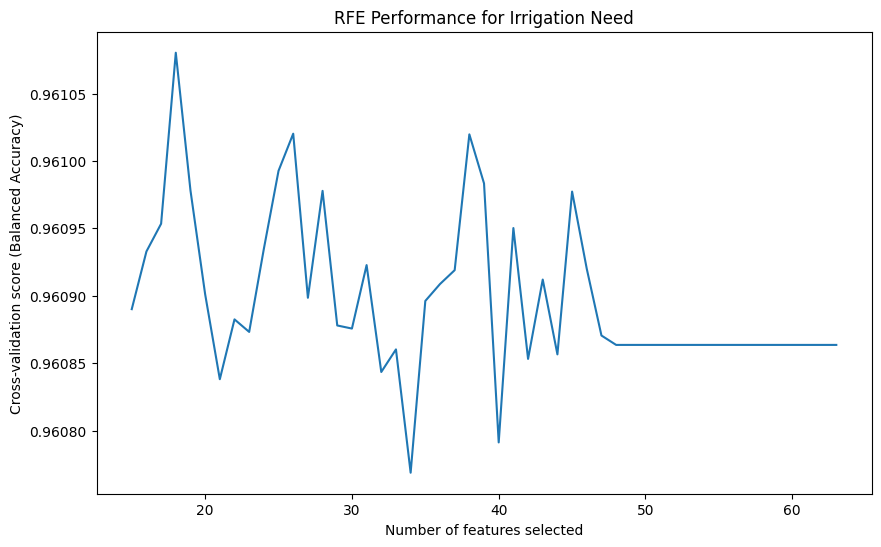


Optimal Features:
['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Wind_Speed_kmh', 'Water_Source', 'Mulching_Used', 'Previous_Irrigation_mm', 'Water_Balance', 'water_balance', 'magic_soil_dry', 'magic_rain_low', 'magic_temp_hot', 'magic_wind_high', 'magic_high_score', 'magic_low_score', 'magic_score', 'magic_dist_to_boundary']


In [8]:
n_jobs = 1 if USE_GPU else -1

X_rfe = X.copy()

# Convert all object and category columns to integer codes
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes
    
if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', category=UserWarning, module='xgboost.core')
    
    # Use a conservative estimator for selection
    # High depth, moderate learning rate to find signal quickly
    clf = xgb.XGBClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=4, 
        tree_method='hist',
        enable_categorical=True,
        device='cpu',
        objective='multi:softprob',
        num_class=3,
        random_state=seed,
        n_jobs=n_jobs
    )

    # Use 'neg_root_mean_squared_error' for regression
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='balanced_accuracy', 
        min_features_to_select=15,
        n_jobs=n_jobs,
        verbose=1
    )

    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plotting results
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (Balanced Accuracy)')
    plt.plot(
        range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('RFE Performance for Irrigation Need')
    plt.show()
    
    # Save the selected features for the next step
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = pd.Index([
        'Soil_Moisture',
        'Temperature_C',
        'Humidity',
        'Rainfall_mm',
        'Wind_Speed_kmh',
        'Water_Source',
        'Mulching_Used',
        'Previous_Irrigation_mm',
        'Water_Balance_Index',
        'water_balance',
        'magic_soil_dry',
        'magic_rain_low',
        'magic_temp_hot',
        'magic_wind_high',
        'magic_high_score',
        'magic_low_score',
        'magic_score',
        'magic_dist_to_boundary'
    ])
        
print('\nOptimal Features:')
print(optimal_cols.tolist())

In [9]:
def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Booster Params
        'n_estimators': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'min_child_weight': trial.suggest_float('min_child_weight', 5.0, 100.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 50.0, log=True),  # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True), # L2
        'gamma': trial.suggest_float('gamma', 0.1, 10.0),
        
        # Tree Structure
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        
        # Boilerplate
        'objective': 'multi:softprob',
        'eval_metric': 'mlogloss',
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'enable_categorical': True,
        'early_stopping_rounds': 50,
        'random_state': seed,
        'n_jobs': n_jobs
    }

    # Ensure optimal_cols is a standard list for filtering
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    oof_preds = np.zeros(len(y), dtype=int)

    # Standard CV Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y)):
        
        # Create Folds
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        
        X_val_fold = training_df.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Restrict to optimal column set
        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]
        
        # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
        obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
        for col in obj_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col]   = X_val_trans[col].astype('category')

        # Create model (Classifier)
        model = xgb.XGBClassifier(**param)

        # Calculate weights to support Balanced Accuracy
        weights = compute_sample_weight('balanced', y_train_fold)
        
        # Train the model
        model.fit(
            X_train_trans, y_train_fold,
            sample_weight=weights,
            eval_set=[(X_val_trans, y_val_fold)],
            verbose=False
        )
        
        # Predict
        preds = model.predict(X_val_trans)
        oof_preds[val_idx] = preds

    return balanced_accuracy_score(y, oof_preds)


In [10]:
if PERFORM_OPTUNA_TUNING:
    print('Starting XGBoost Optuna Optimization...')
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=10
    )
    
    study_xgb = optuna.create_study(
        direction='maximize',
        study_name='xgb_predict_irrigation_need_optuna', 
        pruner=pruner
    )
    
    study_xgb.optimize(
        objective,
        n_trials=25,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print('\nBest Trial:')
    print(f'   Balanced Accuracy: {study_xgb.best_value:.5f}')
    print('   Params: ', study_xgb.best_params)
    
    xgb_best_params = study_xgb.best_params
else:
    xgb_best_params = {
        'learning_rate': 0.036820277842731945,
        'max_depth': 3,
        'min_child_weight': 5.535050075614033,
        'subsample': 0.8151288655255682,
        'colsample_bytree': 0.5292116332226109,
        'reg_alpha': 0.017084601485257762,
        'reg_lambda': 46.61358266104342,
        'gamma': 0.115562381378127,
        'grow_policy': 'depthwise'
    }
    
    print('\nUsing earlier calculated params:')
    print('  Params: ', xgb_best_params)


[I 2026-04-08 08:33:50,391] A new study created in memory with name: xgb_predict_irrigation_need_optuna


Starting XGBoost Optuna Optimization...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-08 08:35:03,351] Trial 0 finished with value: 0.9712983577446433 and parameters: {'learning_rate': 0.06318603304849447, 'max_depth': 4, 'min_child_weight': 20.24032705828725, 'subsample': 0.7453225614073392, 'colsample_bytree': 0.5041841980115125, 'reg_alpha': 0.13146611993357996, 'reg_lambda': 11.332737663036045, 'gamma': 9.10284147443261, 'grow_policy': 'depthwise'}. Best is trial 0 with value: 0.9712983577446433.
[I 2026-04-08 08:35:52,063] Trial 1 finished with value: 0.9707956793016298 and parameters: {'learning_rate': 0.08577649935021099, 'max_depth': 6, 'min_child_weight': 7.819584994382331, 'subsample': 0.8958154369331293, 'colsample_bytree': 0.6491874784843923, 'reg_alpha': 0.07462578033447176, 'reg_lambda': 18.78530148357812, 'gamma': 8.594569941847297, 'grow_policy': 'lossguide'}. Best is trial 0 with value: 0.9712983577446433.
[I 2026-04-08 08:38:28,375] Trial 2 finished with value: 0.9709113300347866 and parameters: {'learning_rate': 0.022806251415901774, 'max_d

## Model Training

In [11]:
xgb_tuned_params = {
    **xgb_best_params, # Unpack Optuna best params
    'n_estimators': 8000,
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'n_jobs': n_jobs,
    'random_state': seed,
    'enable_categorical': True,      # Native categorical support
    'num_class': 3,
    'early_stopping_rounds': 100,
    'tree_method': 'gpu_hist' if USE_GPU else 'hist',
}

print('Final XGBoost CV Training with OOF / Test probabilities')
print('=======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

# Ensure optimal_cols is a standard list
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Initialize Standard K-Fold
n_folds = 5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_probs = np.zeros((len(y), 3))
test_probs = np.zeros((len(test_df), 3))
oof_preds = np.zeros(len(y))

# Standard CV Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y)):
    print(f'Starting processing of fold {fold+1}')

    # Create Folds
    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    X_val_fold = training_df.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Feature Engineering
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)
    
    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    # Guard: ensure no object dtypes slip through (XGB native-cat wants category)
    obj_cols = X_train_trans.select_dtypes(include=['object']).columns.tolist()
    for col in obj_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')
        X_test_trans[col]  = X_test_trans[col].astype('category')

    # Create model (Classifier)
    model = xgb.XGBClassifier(**xgb_tuned_params)

    weights = compute_sample_weight('balanced', y_train_fold)
    
    # Train Model
    model.fit(
        X_train_trans, y_train_fold,
        # eval_set order: [train, validation] so we can track both
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        sample_weight=weights,
        verbose=500
    )
    
    # Store history
    eval_results.append(model.evals_result())
    models.append(model)
    
    # Predict OOF probabilities
    probs = model.predict_proba(X_val_trans)
    preds = model.predict(X_val_trans)
    
    oof_probs[val_idx] = probs
    oof_preds[val_idx] = preds
    
    # Score this fold
    fold_score = balanced_accuracy_score(y_val_fold, preds)
    print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f} (best_iteration={model.best_iteration})')
    
    # Accumulate Test Probs
    test_probs += model.predict_proba(X_test_trans) / n_folds

# Final Metric Calculation
overall_score = balanced_accuracy_score(y, oof_preds)
print(f"Overall Balanced Accuracy Score: {overall_score:.5f}")

Final XGBoost CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.036820277842731945, 'max_depth': 3, 'min_child_weight': 5.535050075614033, 'subsample': 0.8151288655255682, 'colsample_bytree': 0.5292116332226109, 'reg_alpha': 0.017084601485257762, 'reg_lambda': 46.61358266104342, 'gamma': 0.115562381378127, 'grow_policy': 'depthwise', 'n_estimators': 8000, 'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'n_jobs': 1, 'random_state': 10301, 'enable_categorical': True, 'num_class': 3, 'early_stopping_rounds': 100, 'tree_method': 'gpu_hist'}
Starting processing of fold 1
[0]	validation_0-mlogloss:1.06139	validation_1-mlogloss:1.06140
[500]	validation_0-mlogloss:0.07554	validation_1-mlogloss:0.07568
[1000]	validation_0-mlogloss:0.07054	validation_1-mlogloss:0.07122
[1500]	validation_0-mlogloss:0.06762	validation_1-mlogloss:0.06899
[2000]	validation_0-mlogloss:0.06554	validation_1-mlogloss:0.06760
[2500]	validation_0-mlogloss:0.06395	validat

## Visualizing Model Performance
We use four key plots to diagnose the health of our classification model

### Learning Curves (Train vs. Validation Balanced Accuracy)
This plot shows the **Balanced Accuracy** over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Because we use early_stopping_rounds, the model terminates once the validation score plateaus.

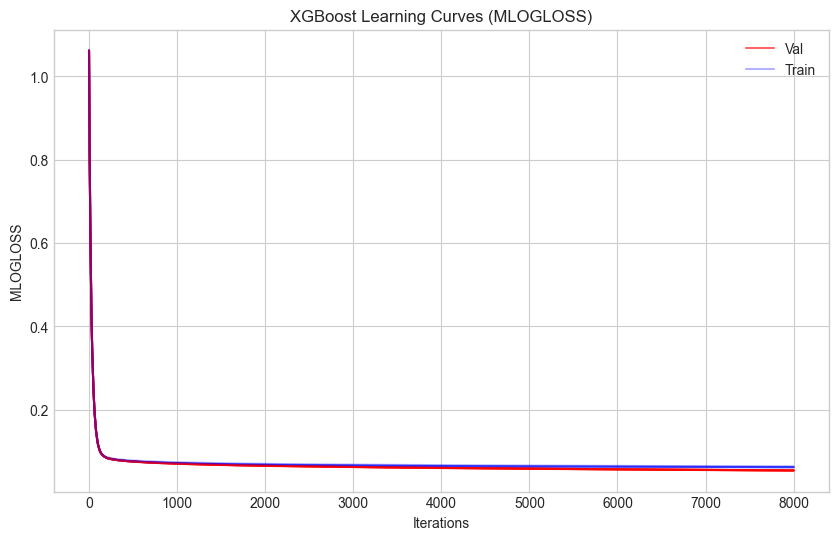

In [12]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results, metric='mlogloss')

### Feature Importance
This bar chart ranks which columns had the biggest impact on the model's predictions.
* **Validation Check:** Ensure the top features align with the high-signal columns identified in the EDA. For this dataset, `tenure` (the strongest numeric predictor) and `PaymentMethod` or `Contract` (the strongest categorical predictors) should likely be at the top.
* **Sanity Check:** If `id` or the original dataset's `customerID` appear in the top rankings, there is a data leakage problem. Additionally, ensure that `TotalCharges` is providing a legitimate signal and not just mirroring `MonthlyCharges` and `tenure` due to the cleaning process required for its formatting.
* **Engineering Check:** Look for the engineered features like `Total_Services` (service density) or financial ratios like `Charges_per_Tenure`. If these appear near the top, it confirms that capturing the cumulative impact of a customer's service profile added predictive power beyond the raw demographic data.

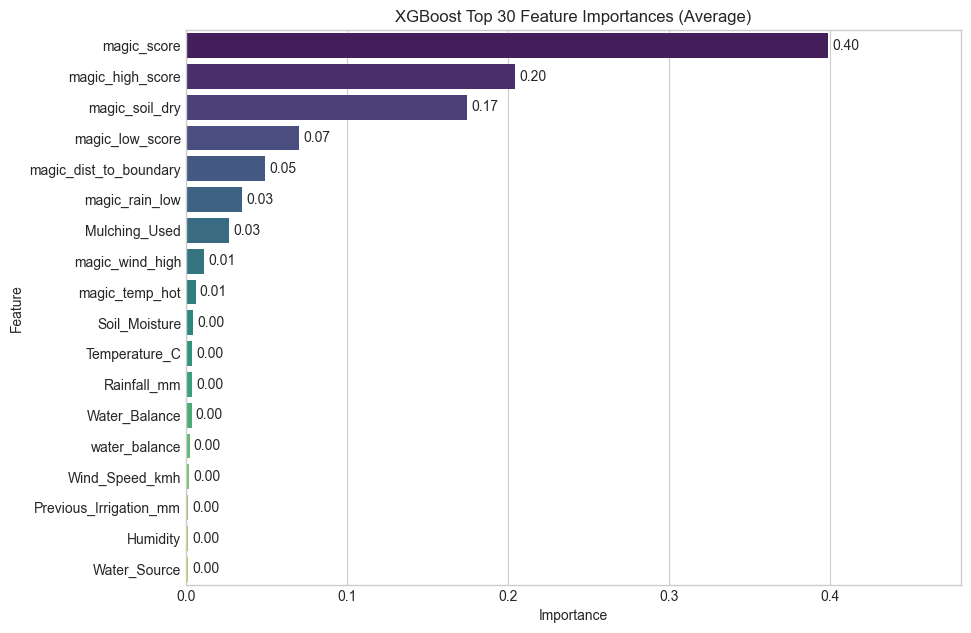

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### Confusion Matrix
The **Confusion Matrix** provides a detailed breakdown of the model's performance by showing how many instances were correctly and incorrectly classified for each class.
* **True Negatives (Top-Left):** Customers who **do not** churn, and the model correctly predicted **No Churn**.
* **False Positives (Top-Right):** Customers who **do not** churn, but the model incorrectly predicted **Churn** (Type I Error).
* **False Negatives (Bottom-Left):** Customers who **do** churn, but the model incorrectly predicted **No Churn** (Type II Error). *In medical diagnostics, this is often the most critical error to minimize.*
* **True Positives (Bottom-Right):** Customers who **do** churn, and the model correctly predicted **Churn**.

Normalized confusion matrix


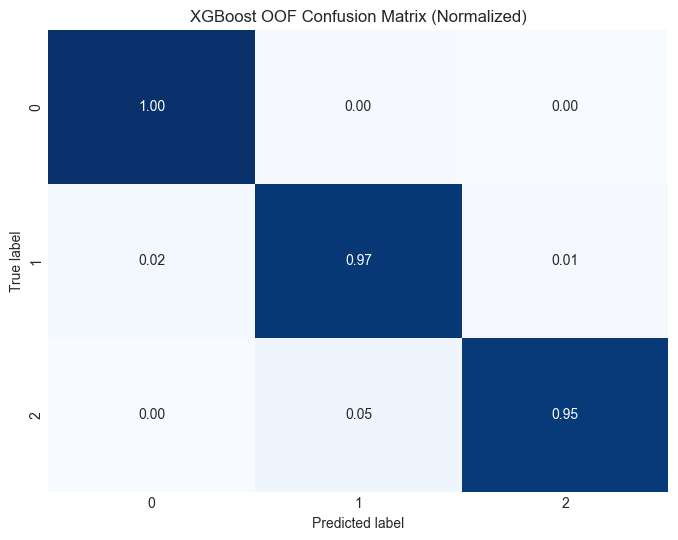

In [14]:
y_pred_class = np.argmax(oof_probs, axis=1)

# Plot the confusion matrix for the 3 irrigation classes [0, 1, 2]
mviz.plot_confusion_matrix(
    y_true=y, 
    y_pred=y_pred_class, 
    classes=[0, 1, 2], 
    normalize=True, 
    title='XGBoost OOF Confusion Matrix (Normalized)'
)

### ROC Curve & AUC
The **Receiver Operating Characteristic (ROC)** curve illustrates the diagnostic ability of our binary classifier system as its discrimination threshold is varied.
* **The Plot:** It plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate (1 - Specificity)**.
* **The Goal:** We want the blue line to hug the top-left corner as closely as possible, maximizing the area under it.
* **AUC Score:** The **Area Under the Curve (AUC)** summarizes the curve into a single number between 0.5 (random guessing) and 1.0 (perfect classification). This is the primary evaluation metric for this competition.

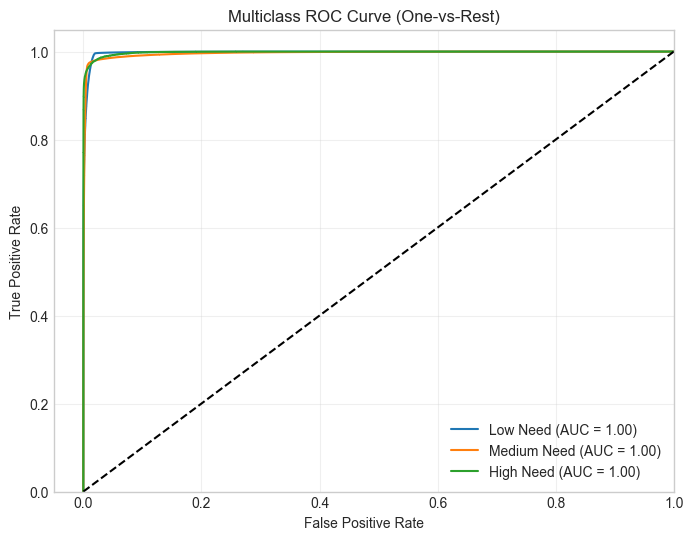

In [15]:
mviz.plot_multiclass_roc_curve(y_true=y, y_score=oof_probs)

## Prepare Submission

We generate the final submission file according to the competition's schema. Since the evaluation metric is Balanced Accuracy, the submission requires the hard predicted class for each crop:

- **0**: Low Irrigation Need
- **1**: Medium Irrigation Need
- **2**: High Irrigation Need

The predictions are derived by selecting the class with the highest predicted probability (**Argmax**) for each sample in the test set.

In [16]:
submission_df = helper.read_dataset('submission')

target_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
numeric_preds = np.argmax(test_probs, axis=1)

# Identify the prediction column from the sample submission
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


In [17]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) probabilities and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).
  
For this multi-class task, we save the full probability distribution (the confidence scores for categories 0, 1, and 2) rather than just the final predicted labels. Saving the raw probabilities is essential for:

- **Weighted Blending**: Combining multiple models by averaging their confidence scores.
- **Stacking**: Using these probabilities as "meta-features" for a secondary model.
- **Calibration Analysis**: Evaluating how well the model's confidence aligns with actual agricultural outcomes.


In [18]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Define column names for the probabilities
prob_cols = ['prob_low', 'prob_medium', 'prob_high']

# Save OOF probabilities
# Create a DF for the probabilities first
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)

# Combine with ID and Target
oof_df = pd.concat([
    pd.DataFrame({
        'id': training_df['id'].values,
        'target': y.values
    }),
    oof_prob_df
], axis=1)

oof_df.to_csv(f'{output_dir}/xgb_oof_probs.csv', index=False)

# Save Test probabilities
test_prob_values_df = pd.DataFrame(test_probs, columns=prob_cols)

test_prob_df = pd.concat([
    pd.DataFrame({
        'id': test_df['id'].values
    }),
    test_prob_values_df
], axis=1)
test_prob_df.to_csv(f'{output_dir}/xgb_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/xgb_oof_probs.csv\n - {output_dir}/xgb_test_probs.csv')

Saved for ensembling:
 - predictions/xgb_oof_probs.csv
 - predictions/xgb_test_probs.csv
